# Assignment 4: Training a DCGAN on Fashion-MNIST

## Objective
Implement and train a Deep Convolutional Generative Adversarial Network (DCGAN) using PyTorch and Fashion-MNIST. The notebook trains for 30 epochs, saves a 4 × 4 grid every 5 epochs, records Generator and Discriminator losses, plots the losses, and compares generated images over time.

**Recommended:** Google Colab with a GPU.

## 1. Imports and Device

In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


## 2. Fashion-MNIST Dataset

Fashion-MNIST contains 28 × 28 grayscale clothing images. Labels are not used for GAN training because the GAN learns from the images themselves. Pixel values are normalized to [-1, 1] to match the Generator's `Tanh` output.

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

batch_size = 128
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Training images:", len(train_dataset))
print("Image shape:", train_dataset[0][0].shape)
print("Batches per epoch:", len(train_loader))

100%|██████████| 26.4M/26.4M [02:41<00:00, 164kB/s] 
100%|██████████| 29.5k/29.5k [00:00<00:00, 197kB/s]
100%|██████████| 4.42M/4.42M [00:04<00:00, 909kB/s] 
100%|██████████| 5.15k/5.15k [00:00<00:00, 40.2MB/s]

Training images: 60000
Image shape: torch.Size([1, 28, 28])
Batches per epoch: 469


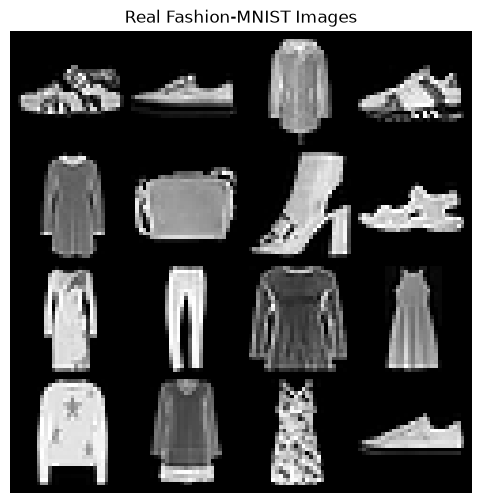

In [5]:
real_batch, _ = next(iter(train_loader))
grid = make_grid(real_batch[:16], nrow=4, normalize=True, padding=2)

plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.title("Real Fashion-MNIST Images")
plt.axis("off")
plt.show()

## 3. Generator

The Generator starts with a random 100-dimensional latent vector and uses transposed convolution layers to increase resolution:

**100 × 1 × 1 → 128 × 7 × 7 → 64 × 14 × 14 → 1 × 28 × 28**

In [6]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 128, 7, 1, 0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

latent_dim = 100
G = Generator(latent_dim).to(device)
print(G)

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 128, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): Tanh()
  )
)


## 4. Discriminator

The Discriminator uses convolution layers to reduce a 28 × 28 image to one real/fake score.

It does not use a final sigmoid because `BCEWithLogitsLoss` already includes the sigmoid operation in a numerically stable form.

In [7]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 1, 7, 1, 0, bias=False)
        )

    def forward(self, x):
        return self.net(x).view(-1)

D = Discriminator().to(device)
print(D)

Discriminator(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 1, kernel_size=(7, 7), stride=(1, 1), bias=False)
  )
)


## 5. Initialization, Loss, and Optimizers

In [8]:
def weights_init(m):
    name = m.__class__.__name__
    if "Conv" in name:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in name:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

G.apply(weights_init)
D.apply(weights_init)

criterion = nn.BCEWithLogitsLoss()
optimizer_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

fixed_noise = torch.randn(16, latent_dim, 1, 1, device=device)

output_dir = "dcgan_outputs"
os.makedirs(output_dir, exist_ok=True)

G_losses = []
D_losses = []
epoch_G_losses = []
epoch_D_losses = []
saved_epochs = []

print("Initialization complete.")

Initialization complete.


## 6. Train for 30 Epochs

A generated 4 × 4 image grid is saved every 5 epochs. The same fixed latent vectors are used for these grids so that visual changes can be compared across training.

Epoch 01/30 | D Loss: 0.3917 | G Loss: 2.2916
Epoch 02/30 | D Loss: 0.4870 | G Loss: 2.1333
Epoch 03/30 | D Loss: 0.7314 | G Loss: 1.6424
Epoch 04/30 | D Loss: 0.8817 | G Loss: 1.4175
Epoch 05/30 | D Loss: 0.9632 | G Loss: 1.3367


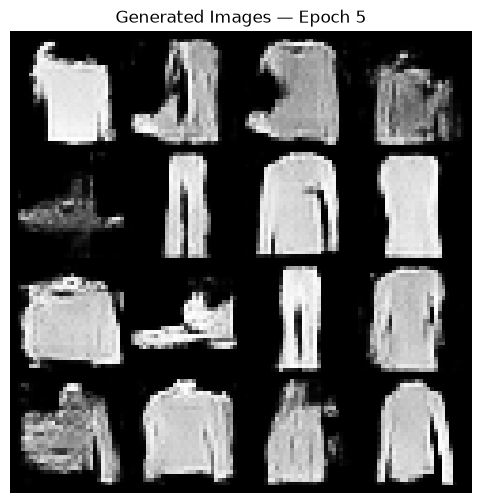

Epoch 06/30 | D Loss: 0.9689 | G Loss: 1.3131
Epoch 07/30 | D Loss: 0.9787 | G Loss: 1.3146
Epoch 08/30 | D Loss: 0.9817 | G Loss: 1.3111
Epoch 09/30 | D Loss: 0.9958 | G Loss: 1.3107
Epoch 10/30 | D Loss: 0.9939 | G Loss: 1.2981


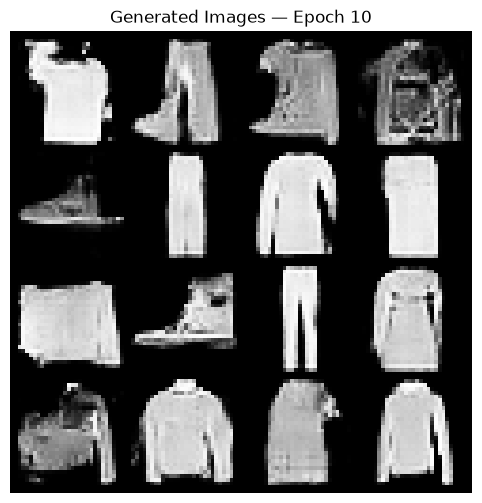

Epoch 11/30 | D Loss: 1.0086 | G Loss: 1.2921
Epoch 12/30 | D Loss: 1.0101 | G Loss: 1.2887
Epoch 13/30 | D Loss: 1.0355 | G Loss: 1.2827
Epoch 14/30 | D Loss: 1.0544 | G Loss: 1.2884
Epoch 15/30 | D Loss: 1.0322 | G Loss: 1.2777


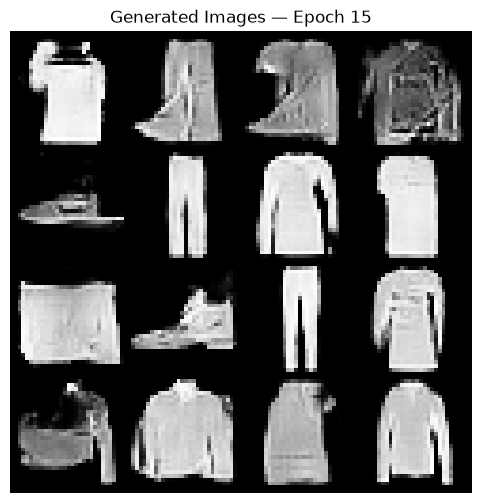

Epoch 16/30 | D Loss: 1.0190 | G Loss: 1.2750
Epoch 17/30 | D Loss: 1.0257 | G Loss: 1.2918
Epoch 18/30 | D Loss: 1.0359 | G Loss: 1.2847
Epoch 19/30 | D Loss: 1.0316 | G Loss: 1.2857
Epoch 20/30 | D Loss: 1.0283 | G Loss: 1.2908


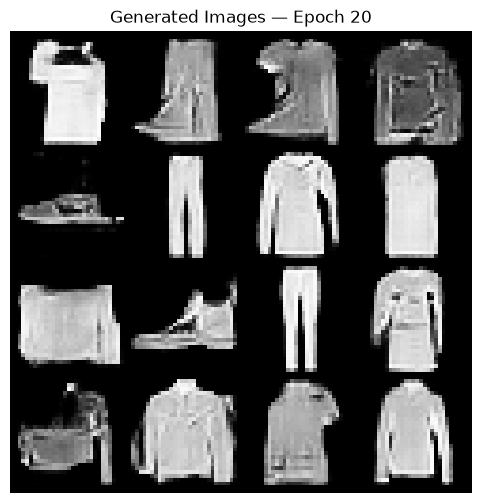

Epoch 21/30 | D Loss: 1.0389 | G Loss: 1.2923
Epoch 22/30 | D Loss: 1.0289 | G Loss: 1.2942
Epoch 23/30 | D Loss: 1.0677 | G Loss: 1.3052
Epoch 24/30 | D Loss: 1.0245 | G Loss: 1.2875
Epoch 25/30 | D Loss: 1.0241 | G Loss: 1.3030


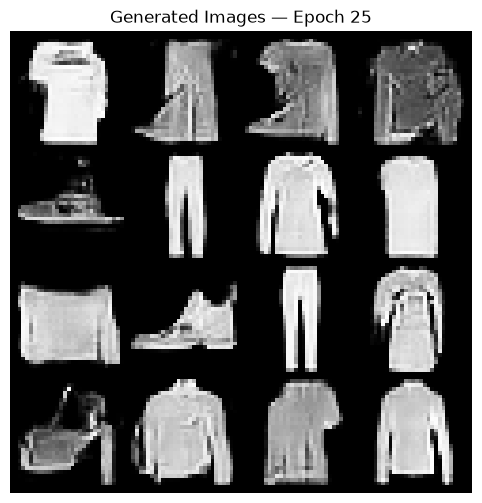

Epoch 26/30 | D Loss: 1.0791 | G Loss: 1.3041
Epoch 27/30 | D Loss: 1.0192 | G Loss: 1.2912
Epoch 28/30 | D Loss: 1.0290 | G Loss: 1.3168
Epoch 29/30 | D Loss: 1.0554 | G Loss: 1.3040
Epoch 30/30 | D Loss: 1.0143 | G Loss: 1.3107


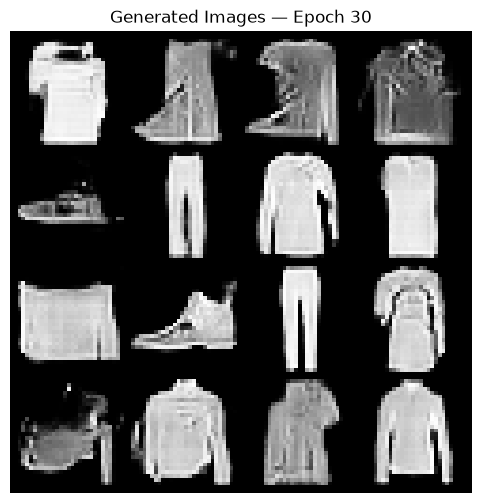

In [9]:
num_epochs = 30

for epoch in range(1, num_epochs + 1):
    total_g = 0.0
    total_d = 0.0

    for real_images, _ in train_loader:
        real_images = real_images.to(device, non_blocking=True)
        n = real_images.size(0)

        # ----- Discriminator -----
        D.zero_grad(set_to_none=True)

        real_labels = torch.ones(n, device=device)
        fake_labels = torch.zeros(n, device=device)

        real_logits = D(real_images)
        loss_real = criterion(real_logits, real_labels)

        noise = torch.randn(n, latent_dim, 1, 1, device=device)
        fake_images = G(noise)

        fake_logits = D(fake_images.detach())
        loss_fake = criterion(fake_logits, fake_labels)

        d_loss = loss_real + loss_fake
        d_loss.backward()
        optimizer_D.step()

        # ----- Generator -----
        G.zero_grad(set_to_none=True)

        fake_logits = D(fake_images)
        g_loss = criterion(fake_logits, real_labels)

        g_loss.backward()
        optimizer_G.step()

        total_d += d_loss.item()
        total_g += g_loss.item()
        D_losses.append(d_loss.item())
        G_losses.append(g_loss.item())

    avg_d = total_d / len(train_loader)
    avg_g = total_g / len(train_loader)

    epoch_D_losses.append(avg_d)
    epoch_G_losses.append(avg_g)

    print(f"Epoch {epoch:02d}/{num_epochs} | D Loss: {avg_d:.4f} | G Loss: {avg_g:.4f}")

    if epoch % 5 == 0:
        G.eval()
        with torch.no_grad():
            samples = G(fixed_noise).cpu()
        G.train()

        filename = os.path.join(output_dir, f"generated_epoch_{epoch:02d}.png")
        save_image(samples, filename, nrow=4, normalize=True, padding=2)

        grid = make_grid(samples, nrow=4, normalize=True, padding=2)
        plt.figure(figsize=(6, 6))
        plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
        plt.title(f"Generated Images — Epoch {epoch}")
        plt.axis("off")
        plt.show()

        saved_epochs.append(epoch)

## 7. Generator and Discriminator Loss Graph

GAN losses do not necessarily decrease smoothly. The two networks are competing, so oscillation is normal. Loss curves should be interpreted together with the generated images.

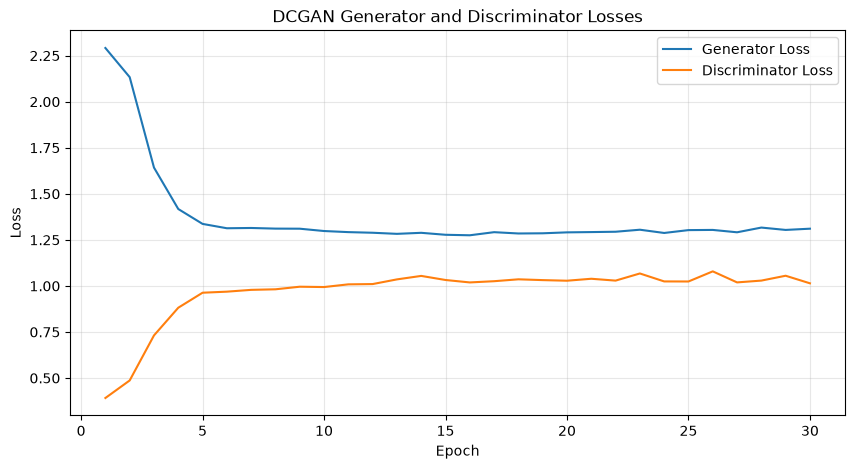

In [10]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, epoch_G_losses, label="Generator Loss")
plt.plot(epochs, epoch_D_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DCGAN Generator and Discriminator Losses")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Generated Images Across Training

Compare epochs 5, 10, 15, 20, 25, and 30. Look for the transition from noise to recognizable clothing shapes, later improvement or plateau, repeated samples, and sudden instability.

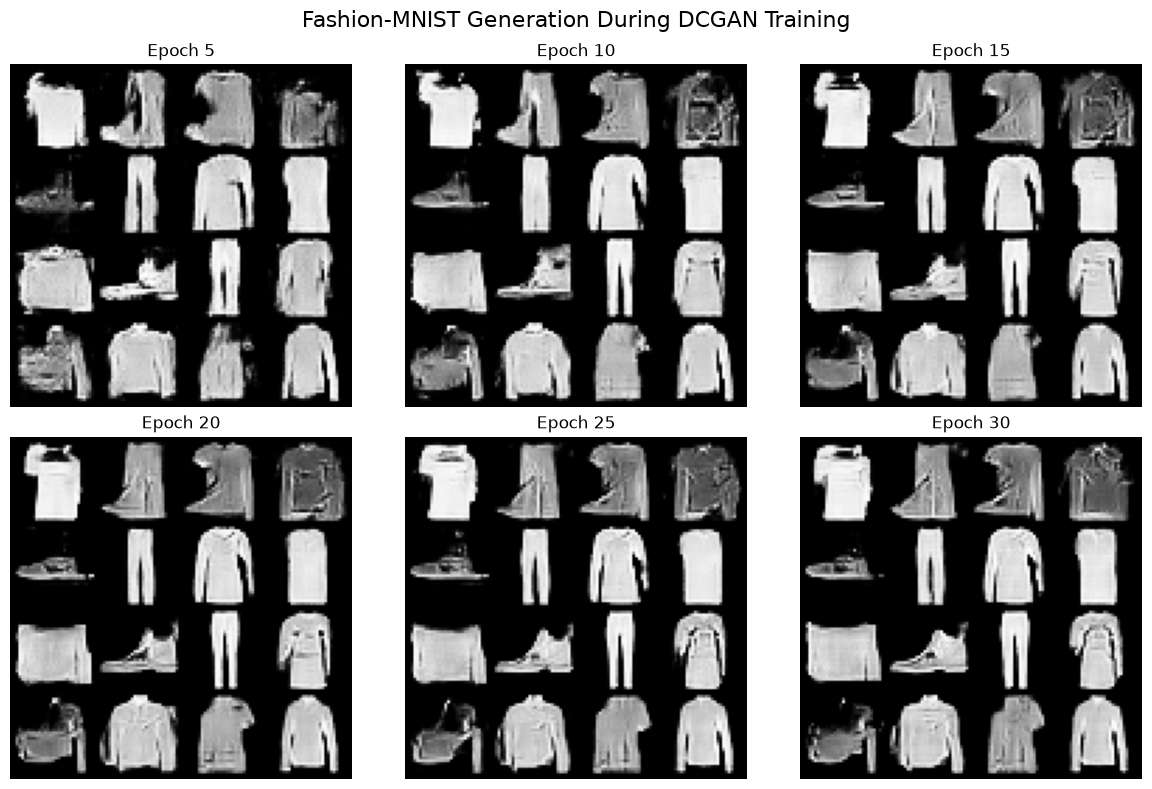

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, epoch in zip(axes.ravel(), saved_epochs):
    filename = os.path.join(output_dir, f"generated_epoch_{epoch:02d}.png")
    image = plt.imread(filename)
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Epoch {epoch}")
    ax.axis("off")

plt.suptitle("Fashion-MNIST Generation During DCGAN Training", fontsize=16)
plt.tight_layout()
plt.show()

## 9. Written Observation

**Early epochs:** Generated images are expected to contain mostly noise and weak shapes because the Generator has not yet learned the visual structure of clothing.

**Middle epochs:** Edges, silhouettes, and recognizable clothing-like forms should begin to appear as the Generator learns from feedback from the Discriminator.

**Later epochs:** Samples should generally become more structured. Improvement may eventually plateau because GAN optimization is a competitive process rather than ordinary one-directional minimization.

**Mode collapse / instability:** Check whether multiple images become nearly identical. If so, this may indicate mode collapse. Sudden deterioration or large visual changes between checkpoints may indicate instability.

**Important:** Replace these general statements with your actual observations after running the notebook. Record the first epoch where you can clearly recognize clothing shapes and whether quality appears to plateau by epoch 30.

## 10. Conclusion

The DCGAN demonstrates adversarial learning using two competing networks. The Generator learns to transform random noise into Fashion-MNIST-like images, while the Discriminator learns to distinguish generated images from real clothing images. As training progresses, generated samples generally move from random patterns toward more recognizable structures. Because GAN training is competitive, loss curves can fluctuate and visual quality does not necessarily improve monotonically. The saved image grids provide the most useful evidence for evaluating training progress, quality improvement, plateauing, mode collapse, and instability.